# AirGuard — L3 EDA (Cleaning + Exploration)

**What this notebook does**
1. Loads raw Cairo air-quality + weather (from Postgres if the DB is up, else a
   live Open-Meteo fetch as a fallback).
2. Cleans both with `src/clean.py` (dedup, hourly grid, gap-fill).
3. Explores: distributions, a `pm2_5` time series, correlations, and the health-
   category balance.
4. Computes the **persistence baseline** — the single most important number in
   this whole project (see Risks). Our model in L5 must beat it, or the project
   is pointless. This notebook decides *which forecast horizon* to target.

> **Honesty note.** Open-Meteo air quality is CAMS reanalysis (model output),
> not raw sensors. That is exactly why it is gap-free below. We use it for
> complete coverage; ground sensors (OpenAQ) are future work.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make src importable when the notebook runs from notebooks/
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# --- config ---
CITY = "Cairo"
START, END = "2024-01-01", "2024-12-31"   # a full year of hourly history
print("EDA window:", START, "->", END)


EDA window: 2024-01-01 -> 2024-12-31


## 1. Load data
Try the pipeline's own store (Postgres, filled by L1→L2). If the DB isn't
running, fall back to a direct Open-Meteo fetch so the notebook still runs.


In [2]:
from src.ingest import fetch_air_quality, fetch_weather

def load(table, fetch):
    """Read from Postgres; on any failure, fetch live from Open-Meteo."""
    try:
        from src.storage import read_table
        df = read_table(table, city=CITY, start=START, end=END)
        if len(df):
            print(f"{table}: {len(df)} rows from Postgres")
            return df
        print(f"{table}: DB empty, falling back to live fetch")
    except Exception as e:
        print(f"{table}: DB unavailable ({type(e).__name__}), live fetch")
    df = fetch(START, END)
    print(f"{table}: {len(df)} rows from Open-Meteo")
    return df

raw_air = load("raw_air_pollution", fetch_air_quality)
raw_wx  = load("raw_weather", fetch_weather)
raw_air.head(3)


raw_air_pollution: 8761 rows from Postgres
raw_weather: 8761 rows from Postgres


,id,city,lat,lon,dt_utc,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,aerosol_optical_depth,us_aqi,ingested_at
0,481,Cairo,30.0444,31.2357,2024-01-01 00:00:00+00:00,39.1,52.4,548.0,62.3,58.4,1.0,1.0,0.11,93.0,2026-09-02 00:08:35.495585+00:00
1,482,Cairo,30.0444,31.2357,2024-01-01 01:00:00+00:00,42.2,55.2,565.0,60.1,59.1,2.0,1.0,0.11,96.0,2026-09-02 00:08:35.495585+00:00
2,483,Cairo,30.0444,31.2357,2024-01-01 02:00:00+00:00,41.6,58.6,505.0,56.4,60.3,3.0,1.0,0.10,96.0,2026-09-02 00:08:35.495585+00:00


## 2. Clean (L3) and check the effect

In [3]:
from src.clean import clean_dataframe, count_gaps

print("gaps vs complete hourly grid (before clean):")
print("  air    :", count_gaps(raw_air))
print("  weather:", count_gaps(raw_wx))

air = clean_dataframe(raw_air)
wx  = clean_dataframe(raw_wx)

print("\nafter clean:")
print("  air rows   :", len(air), "| duplicate hours:", air.duplicated(['city','dt_utc']).sum())
print("  weather rows:", len(wx), "| duplicate hours:", wx.duplicated(['city','dt_utc']).sum())
print("  nulls in pm2_5:", air['pm2_5'].isna().sum())


gaps vs complete hourly grid (before clean):
  air    : 0
  weather: 0

after clean:
  air rows   : 8761 | duplicate hours: 0
  weather rows: 8761 | duplicate hours: 0
  nulls in pm2_5: 0


## 3. Join air + weather
Both sit on the same hourly UTC grid, so they merge on `dt_utc` with no
misalignment (verified in L1). This joined frame is what EDA and L4 features use.


In [4]:
df = air.merge(wx, on=["city", "lat", "lon", "dt_utc"], how="inner")
df = df.sort_values("dt_utc").reset_index(drop=True)
print("joined:", df.shape, "|", df['dt_utc'].min(), "->", df['dt_utc'].max())
df.head(3)


joined: (8761, 24) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 00:00:00+00:00


,dt_utc,id_x,city,lat,lon,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,...,ingested_at_x,id_y,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,cloud_cover,precipitation,ingested_at_y
0,2024-01-01 00:00:00+00:00,481,Cairo,30.0444,31.2357,39.1,52.4,548.0,62.3,58.4,...,2026-09-02 00:08:35.495585+00:00,97,12.8,93.0,1019.0,6.4,16.0,0.0,0.0,2026-09-02 00:08:42.858107+00:00
1,2024-01-01 01:00:00+00:00,482,Cairo,30.0444,31.2357,42.2,55.2,565.0,60.1,59.1,...,2026-09-02 00:08:35.495585+00:00,98,11.9,97.0,1019.0,6.2,350.0,0.0,0.0,2026-09-02 00:08:42.858107+00:00
2,2024-01-01 02:00:00+00:00,483,Cairo,30.0444,31.2357,41.6,58.6,505.0,56.4,60.3,...,2026-09-02 00:08:35.495585+00:00,99,11.2,99.0,1018.9,7.9,3.0,8.0,0.0,2026-09-02 00:08:42.858107+00:00


## 4. Distributions
What do the key variables actually look like?

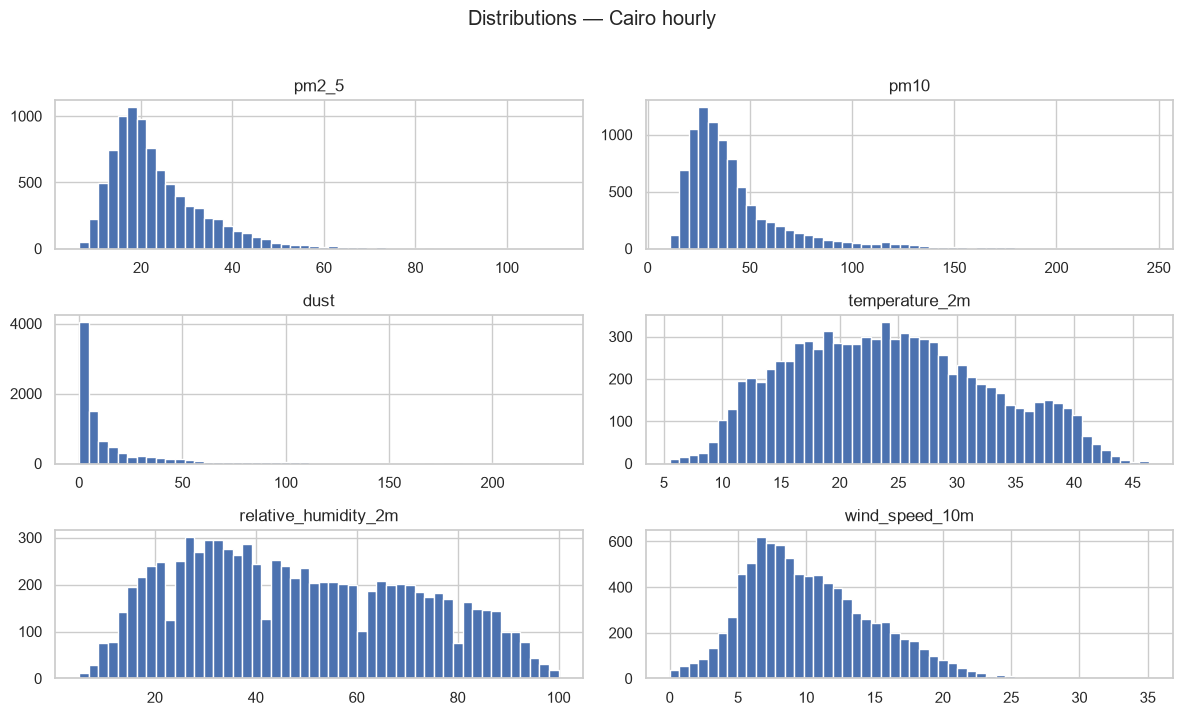

,pm2_5,pm10,dust,temperature_2m,relative_humidity_2m,wind_speed_10m
count,8761.00,8761.00,8761.00,8761.00,8761.00,8761.00
mean,23.74,43.44,16.88,24.25,48.55,10.24
std,11.49,28.33,28.07,8.34,22.81,4.63
min,6.50,10.80,0.00,5.50,5.00,0.00
25%,16.30,26.20,2.00,17.70,30.00,6.80
50%,20.70,35.00,5.00,23.80,46.00,9.50
75%,28.30,49.30,17.00,30.20,67.00,13.20
max,111.30,245.30,232.00,46.40,100.00,35.10


In [5]:
cols = ["pm2_5", "pm10", "dust", "temperature_2m", "relative_humidity_2m", "wind_speed_10m"]
axes = df[cols].hist(bins=50, figsize=(12, 7))
plt.suptitle("Distributions — Cairo hourly", y=1.02)
plt.tight_layout(); plt.show()

df[cols].describe().round(2)


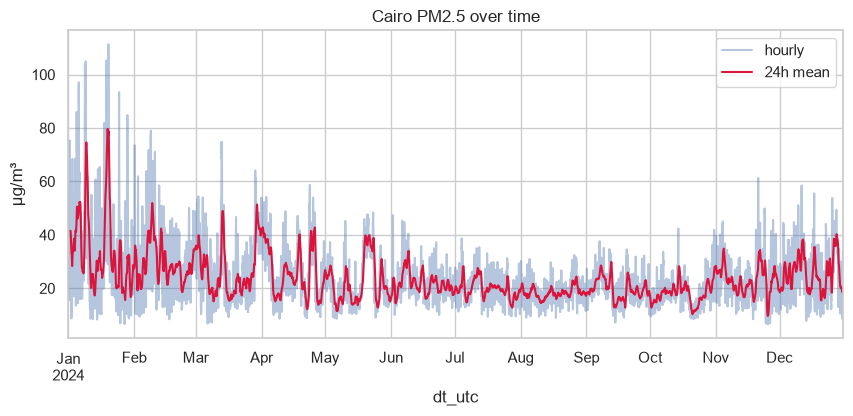

In [6]:
# pm2_5 over time, with a 24h rolling mean to show the daily rhythm
s = df.set_index("dt_utc")["pm2_5"]
ax = s.plot(alpha=0.4, label="hourly")
s.rolling(24).mean().plot(ax=ax, color="crimson", label="24h mean")
ax.set_title("Cairo PM2.5 over time"); ax.set_ylabel("µg/m³"); ax.legend(); plt.show()


## 5. Correlations
Which variables move with PM2.5? This guides which features matter in L4.


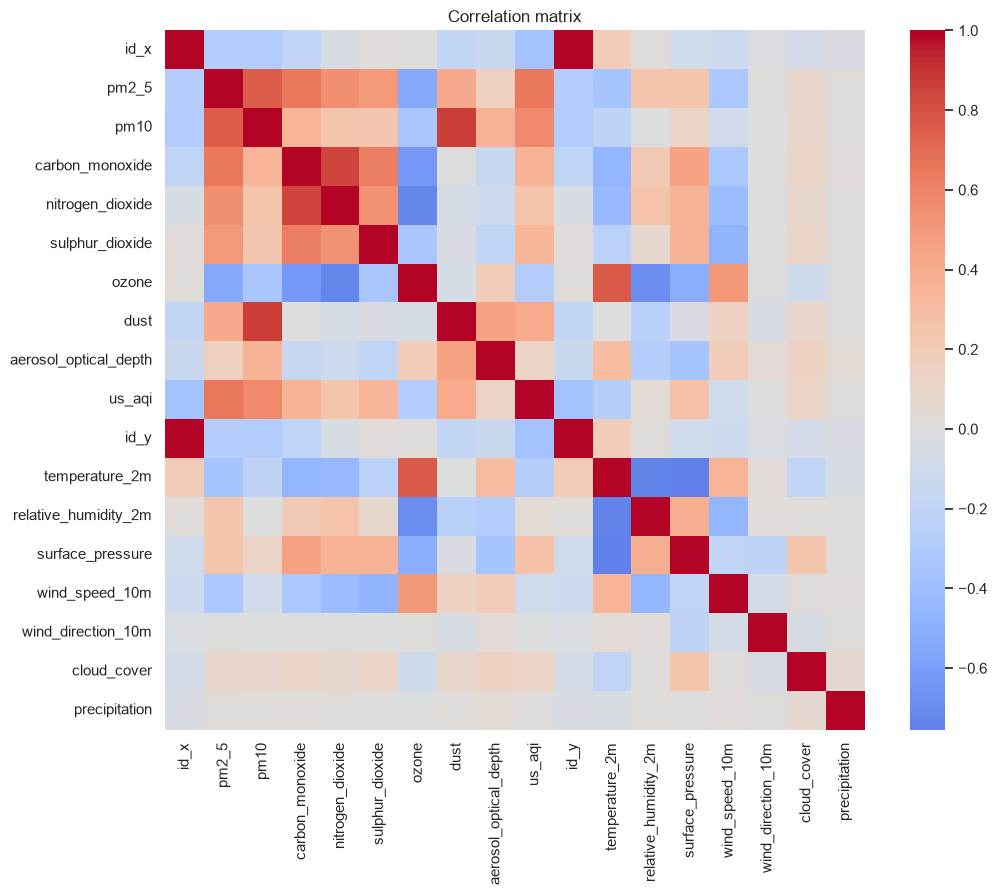

Top correlates of pm2_5:
pm10                0.756
us_aqi              0.647
carbon_monoxide     0.646
nitrogen_dioxide    0.549
ozone              -0.530
sulphur_dioxide     0.498
dust                0.415
temperature_2m     -0.353
Name: pm2_5, dtype: float64


In [7]:
num = df.select_dtypes("number").drop(columns=["lat", "lon"], errors="ignore")
corr = num.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

print("Top correlates of pm2_5:")
print(corr["pm2_5"].drop("pm2_5").sort_values(key=abs, ascending=False).head(8).round(3))


## 6. Health-category balance
Map PM2.5 to a simplified 4-level advisory and look at the class balance. Cairo
is expected to skew Moderate/Unhealthy — if a classifier is kept in L5, this
imbalance means we judge it on F1/recall, not accuracy (see Risks #4).

> Thresholds below are an illustrative simplification (µg/m³); the exact
> breakpoints are finalised with the serving layer in L6.


pm2_5
Good          6.7 %
Moderate     80.3 %
Unhealthy    10.9 %
Hazardous     2.0 %
Name: count, dtype: str


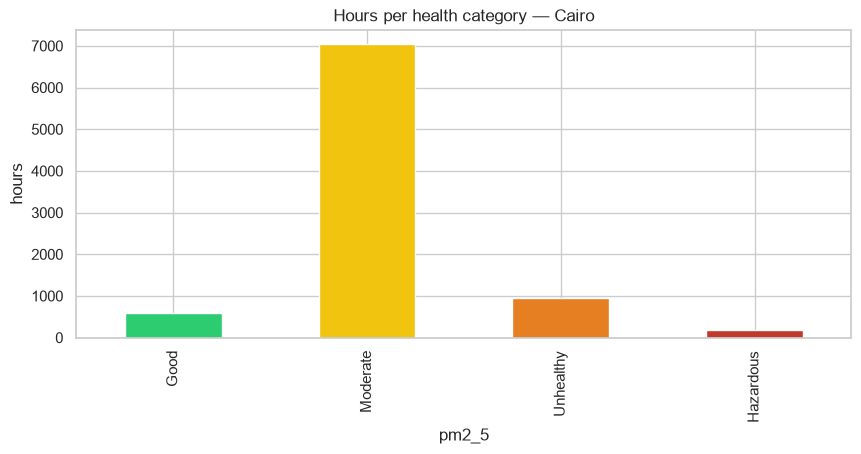

In [8]:
def categorize(pm):
    if pm <= 12:    return "Good"
    if pm <= 35.4:  return "Moderate"
    if pm <= 55.4:  return "Unhealthy"
    return "Hazardous"

order = ["Good", "Moderate", "Unhealthy", "Hazardous"]
cat = df["pm2_5"].apply(categorize).astype("category").cat.set_categories(order)
counts = cat.value_counts().reindex(order)
print((counts / counts.sum() * 100).round(1).astype(str) + " %")

counts.plot(kind="bar", color=["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"])
plt.title("Hours per health category — Cairo"); plt.ylabel("hours"); plt.show()


## 7. Persistence baseline — the decisive test
**The naive baseline is "the next value equals the current value."** Because
PM2.5 is highly autocorrelated, this is a strong baseline at short horizons and
weakens as the horizon grows.

For each horizon *N* hours we measure how wrong persistence is (MAE / RMSE).
**In L5, XGBoost must beat these numbers.** Where the baseline is weak enough to
beat by a useful margin *and* the forecast is still useful is where we set the
target horizon *N*.


In [9]:
def persistence_scores(series, horizons=(1, 3, 6, 12, 24)):
    """MAE/RMSE of predicting value(t+N) with value(t), per horizon."""
    rows = []
    y = series.to_numpy(dtype=float)
    for n in horizons:
        pred, true = y[:-n], y[n:]        # shift by N hours
        err = true - pred
        rows.append({
            "horizon_h": n,
            "MAE": np.mean(np.abs(err)),
            "RMSE": np.sqrt(np.mean(err ** 2)),
        })
    return pd.DataFrame(rows).round(3)

baseline = persistence_scores(df["pm2_5"])
baseline


,horizon_h,MAE,RMSE
0,1,2.234,3.592
1,3,5.183,8.005
2,6,7.846,11.567
3,12,9.345,12.942
4,24,6.603,10.219


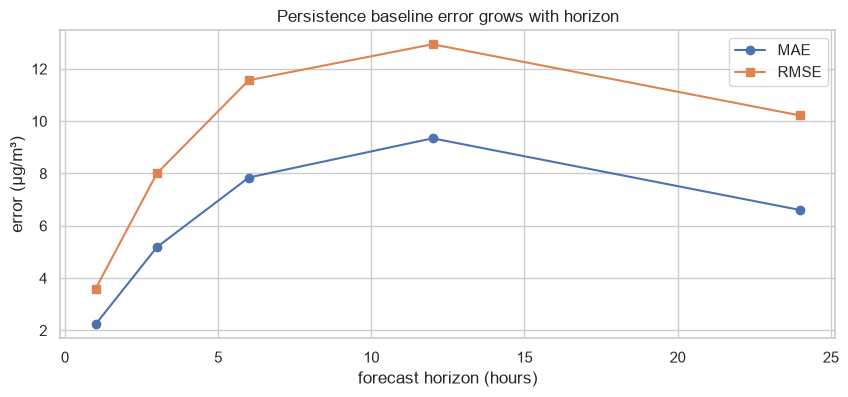

Mean pm2_5: 23.74 µg/m³  — put the errors above in context.


In [10]:
fig, ax = plt.subplots()
ax.plot(baseline["horizon_h"], baseline["MAE"], "o-", label="MAE")
ax.plot(baseline["horizon_h"], baseline["RMSE"], "s-", label="RMSE")
ax.set_xlabel("forecast horizon (hours)"); ax.set_ylabel("error (µg/m³)")
ax.set_title("Persistence baseline error grows with horizon")
ax.legend(); plt.show()

print("Mean pm2_5:", round(df['pm2_5'].mean(), 2), "µg/m³  — put the errors above in context.")


### Interpretation — Cairo 2024 (8,784 hours, 0 gaps)

**Persistence baseline (MAE, µg/m³):** 1h → 2.23 · 3h → 5.18 · 6h → 7.85 ·
12h → **9.35** · 24h → 6.60. Mean PM2.5 is only **23.7 µg/m³**, so put every
error in that context.

- **1h is nearly unbeatable.** A 2.23 error on a ~24 mean is ~9%; PM2.5 barely
  moves in an hour. An ML model here will likely only *match* persistence — a
  1h demo risks looking pointless (Risk #1, confirmed).
- **Error peaks at 12h, then FALLS at 24h.** That dip is Cairo's strong daily
  cycle — "same hour tomorrow ≈ same hour today" makes the 24h naive guess good
  again. So 24h is *not* the easy win it looks like.
- **Target horizon = 6–12h.** That is where the naive baseline is weakest
  (largest headroom) while the forecast is still actionable. L5 must show
  XGBoost beating ~7.9 (6h) / ~9.4 (12h) MAE by a clear margin.

**Class balance:** ~80% Moderate, ~11% Unhealthy, ~7% Good, ~2% Hazardous.
Heavily imbalanced → if a classifier is kept in L5, judge it on **F1/recall**,
not accuracy (Risk #4). (Note: 2024 skews *Moderate*, not "Unhealthy" as first
assumed — a small honest correction from the real data.)

**Top PM2.5 correlates:** pm10 (0.76), carbon_monoxide (0.65), us_aqi (0.65),
nitrogen_dioxide (0.55), ozone (−0.53). Co-pollutants dominate; `dust` matters
in seasonal Saharan events rather than year-round average.

**L3 done:** clean frame (no dupes, no gaps, no impossible values), distributions
+ correlation shown, persistence baseline computed. → Next: L4 features.
